## Read and Setup the dataset

In [1]:
import pandas as pd
fp = "../data/monthly-car-sales.csv"
df = pd.read_csv(fp)

In [2]:
cols = ["date", "signal"]
df.columns = cols
df["date"] = pd.to_datetime(df.date)

In [3]:
series = df.signal
series.index = df.date

## Setup Observation Logging 
We will be using Jinja templates to log observations about the data as we discover them. The observations are collected in a list and then logged to KMDS finally.

In [4]:
from observation_log import ObservationTemplates, ObsCat
ObservationTemplates.SOURCE_DATA


'{{source_details}}'

In [5]:
ts_obs = []

In [6]:
from jinja2 import Template
src_det = "Data was from kaggle, however, it looks like it can be traced to https://www.york.ac.uk/depts/maths/data/ts/"
src_det += ". However, it appears in the time series data library as well. Looks like a publicly available dataset."
data = {"source_details":  src_det
}

j2_template = Template(ObservationTemplates.SOURCE_DATA)
rendered_output = j2_template.render(data)
obs = (ObsCat.SOURCE_DATA, rendered_output)
ts_obs.append(obs)

In [7]:
ObservationTemplates.PREPROCESSING

'{{preprocessing_details}}'

In [8]:
pp_det = "SSA does standardization as part of preprocessing, no missing values"
data = {"preprocessing_details":  pp_det
}

j2_template = Template(ObservationTemplates.PREPROCESSING)
rendered_output = j2_template.render(data)
obs = (ObsCat.PREPROCESSING, rendered_output)
ts_obs.append(obs)

In [9]:
ObservationTemplates.TASKS

'{{task_details}}'

In [10]:
task_det = "This is analysis, not modeling. This dataset may be a candidate for pattern mining, forecasting, among others."
data = {"task_details":  task_det
}

j2_template = Template(ObservationTemplates.TASKS)
rendered_output = j2_template.render(data)
obs = (ObsCat.TASKS, rendered_output)
ts_obs.append(obs)

In [11]:
ObservationTemplates.UPDATE

'{{update_details}}'

In [12]:
update_det = "This is an old dataset, it will not get updated."
data = {"update_details":  task_det
}

j2_template = Template(ObservationTemplates.UPDATE)
rendered_output = j2_template.render(data)
obs = (ObsCat.UPDATE, rendered_output)
ts_obs.append(obs)

### Basic Descriptive Statistics

In [13]:
from scipy.stats import iqr
import numpy as np
data = df.signal.values
# Calculate the IQR
# Default percentiles are (25, 75)
iqr_value = iqr(data)
print(f"IQR: {iqr_value}")

# Calculate Q1 and Q3 manually using numpy for demonstration of bounds calculation
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(f"Q1: {Q1}, Q3: {Q3}")

# Calculate bounds
lower_bound = Q1 - 1.5 * iqr_value
upper_bound = Q3 + 1.5 * iqr_value
outlier = (data < lower_bound) | (data > upper_bound)
df["outlier"] = outlier

IQR: 6204.5
Q1: 11391.25, Q3: 17595.75


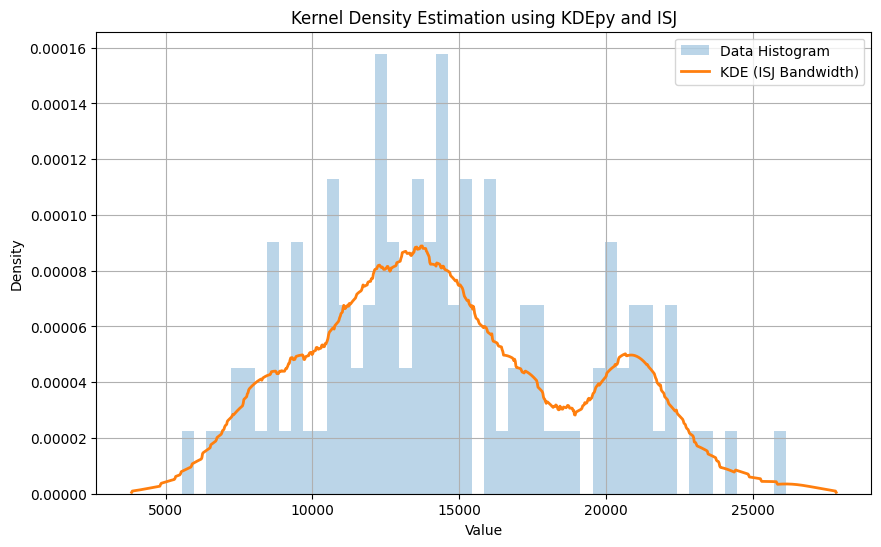

In [14]:

import matplotlib.pyplot as plt
from KDEpy import FFTKDE
from scipy.stats import norm

# 1. Generate or define a sample signal (multimodal data)
np.random.seed(42)
data = df.signal.values

# 2. Compute density estimates using 'ISJ' - Improved Sheather Jones
# FFTKDE is fast for large datasets
x, y = FFTKDE(kernel='gaussian', bw='ISJ').fit(data).evaluate(2**10)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.3, label='Data Histogram')
plt.plot(x, y, label='KDE (ISJ Bandwidth)', linewidth=2)
plt.title('Kernel Density Estimation using KDEpy and ISJ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
data = {"num_samples": df.shape[0],
"sampling_rate": "monthly (first day of month)",
"mean" : np.mean(df.signal),
"std": np.std(df.signal),
 "modality": "multimodal"
}


j2_template = Template(ObservationTemplates.DESCRIPTIVE_STATISTICS)
rendered_output = j2_template.render(data)
from observation_log import ObsCat
obs = (ObsCat.DESCRIPTIVE_STATISTICS, rendered_output)
ts_obs.append(obs)

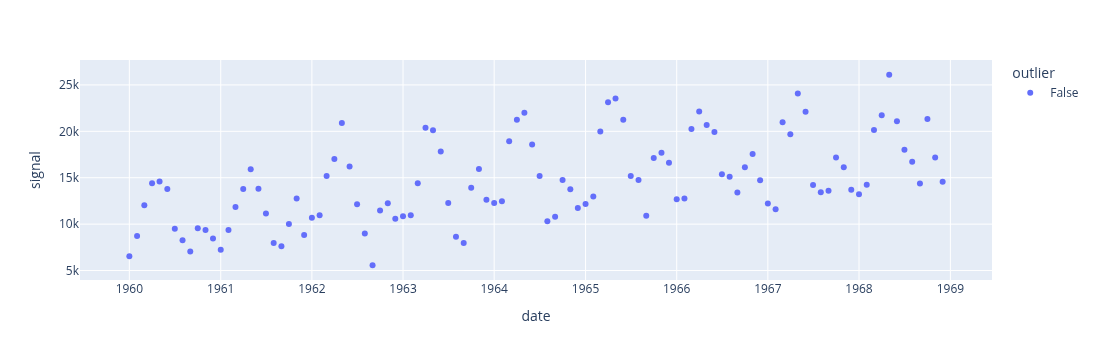

In [16]:
import plotly.express as px


# Create the line plot with markers
fig = px.scatter(df, x="date", y="signal", color="outlier")

# Display the figure
fig.show()

In [17]:
outlier_prop = df[df.outlier == True].shape[0]/df.shape[0]

In [18]:
outlier_prop

0.0

In [19]:
data = {"outlier_proportion": outlier_prop
}

j2_template = Template(ObservationTemplates.OUTLIERS)
rendered_output = j2_template.render(data)

In [20]:
data = {"remarks": """No outliers, two distinct seasonalities, gradual monotonic trend."""
}

j2_template = Template(ObservationTemplates.RAW_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.RAW_PLOTS, rendered_output)
ts_obs.append(obs)

## Prepare for SSA
1. Define Window Size
2. Run SSA
3. Inspect Eigen Value Plot


In [21]:
from ssalib import SingularSpectrumAnalysis
wdw = 24 # 12 gives a worse reconstruction
ssa = SingularSpectrumAnalysis(series, window=wdw)

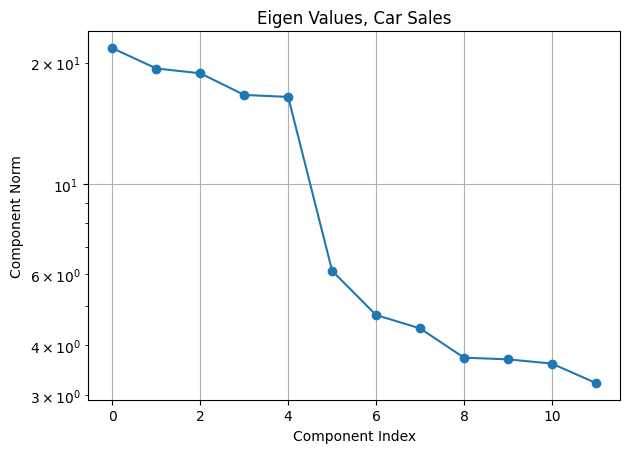

In [22]:
ssa.decompose()
# Visualize results, in this case, singular values

fig, ax = ssa.plot(n_components=12, marker='o')
plt.title("Eigen Values, Car Sales")
plt.grid(True)

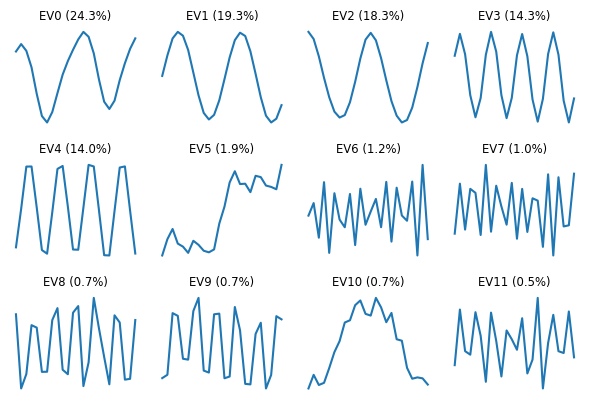

In [23]:
fig, axes = ssa.plot(kind='vectors')

In [24]:
import numpy as np

# Suppose 's' contains the singular values from SVD
# s = [sigma1, sigma2, ..., sigmaL]
eigenvalues = ssa.eigenvalues
total_variance = np.sum(eigenvalues)
exp_var = {"var_comp-" + str(i+1) : (eigenvalues[i]/total_variance).item() for i in range(eigenvalues.shape[0])}
cum_var = {"var_comp-" + str(i+1) : (np.sum(eigenvalues[:i+1])/total_variance).item() for i in range(eigenvalues.shape[0])}

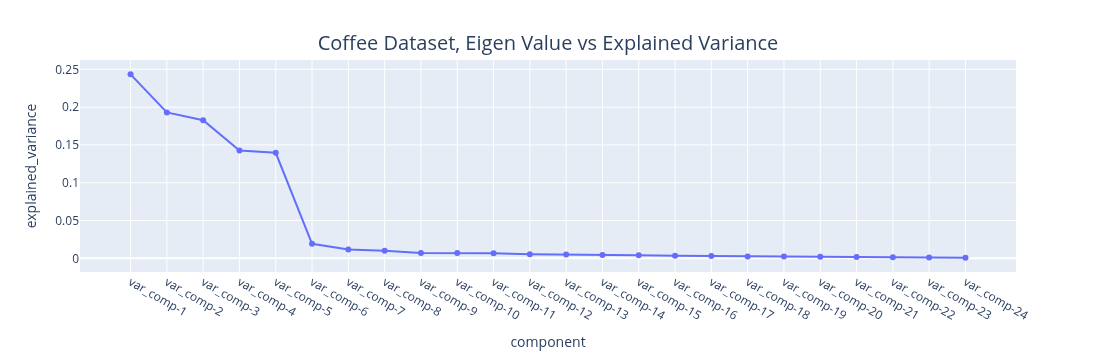

In [25]:
import plotly.express as px
df_eig = pd.DataFrame.from_dict(exp_var, orient="index").reset_index()
df_eig.columns = ["component", "explained_variance"]
# Create the line plot with markers
fig = px.line(df_eig, x="component", y="explained_variance", markers=True)
fig.update_layout(
    title={
        'text': "Coffee Dataset, Eigen Value vs Explained Variance",
        'y':0.9, # Position (0-1)
        'x':0.5, # Position (0-1)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=20)
    }
)
# Display the figure
fig.show()

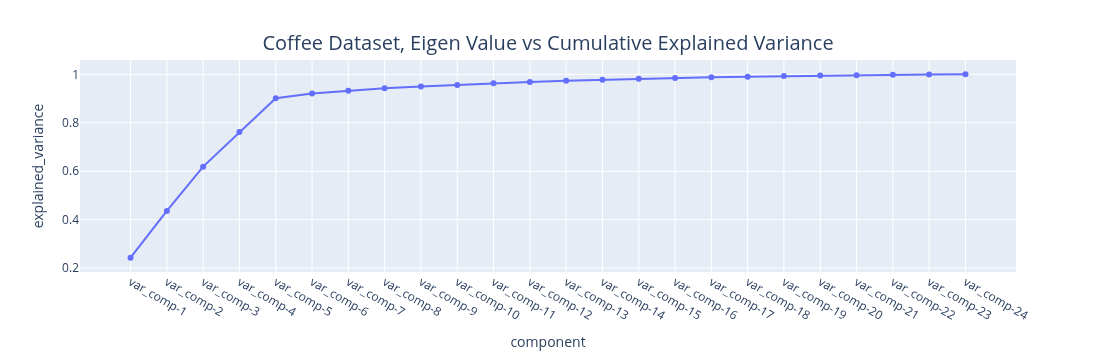

In [26]:

df_cv = pd.DataFrame.from_dict(cum_var, orient="index").reset_index()
df_cv.columns = ["component", "explained_variance"]

# Create the line plot with markers
fig = px.line(df_cv, x="component", y="explained_variance", markers=True)
fig.update_layout(
    title={
        'text': "Coffee Dataset, Eigen Value vs Cumulative Explained Variance",
        'y':0.9, # Position (0-1)
        'x':0.5, # Position (0-1)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=20)
    }
)

# Display the figure
fig.show()

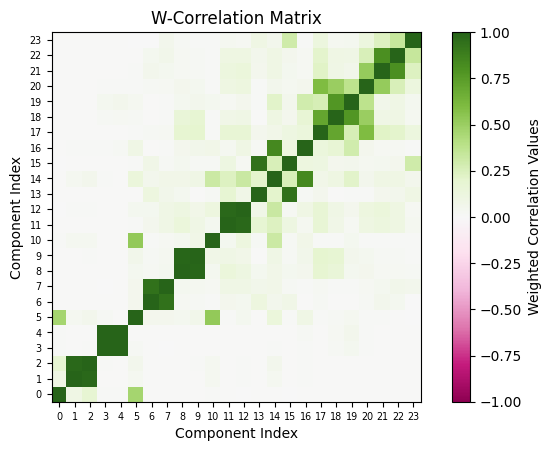

In [27]:
fig, ax = ssa.plot(kind='wcorr', n_components=24)
_ = ax.set_xlabel('Component Index')
_ = ax.set_ylabel('Component Index')
cbar = ax.collections[0].colorbar
cbar.set_label('Weighted Correlation Values')

## Apply Grouping

In [28]:
ssa.reconstruct(groups={'Trend': [0], 'Seasonal': [1,2,3,4,5,6,7], "residuals":[8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]})

SingularSpectrumAnalysis(timeseries=<Series shape=(108,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

## Residual Analysis

In [29]:
25+19.3 + 18.3 + 14.3 + 14.0

90.89999999999999

In [30]:
import numpy as np
noise_signal = ssa["residuals"].values
median_value_noise = np.median(noise_signal)
binarized_signal = noise_signal > median_value_noise

In [31]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [32]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 2.230622021932288


<Axes: ylabel='Density'>

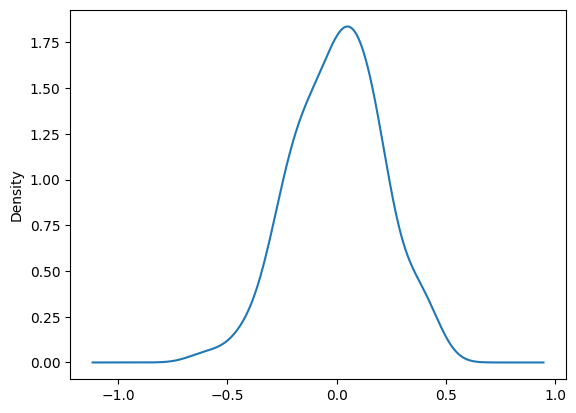

In [33]:
ssa["residuals"].plot.kde()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

<Axes: xlabel='date'>

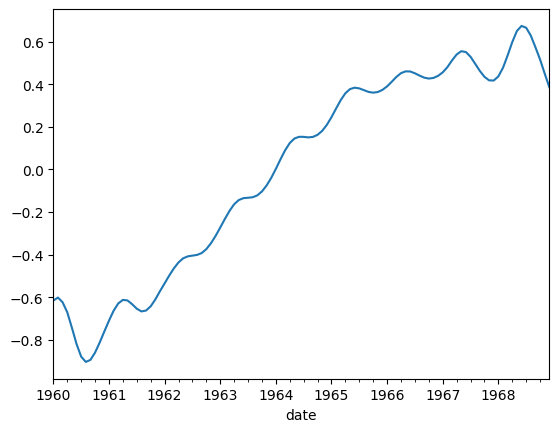

In [34]:
ssa["Trend"].plot()

<Axes: xlabel='date'>

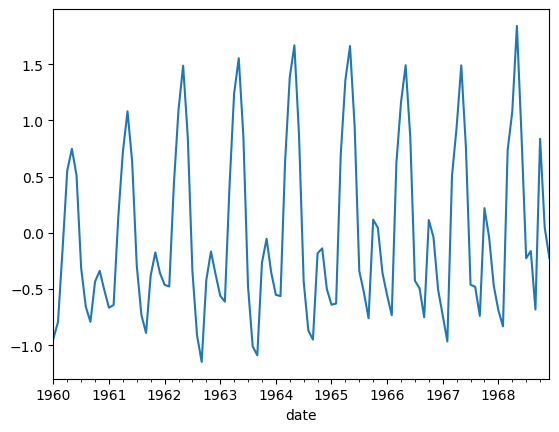

In [35]:
ssa["Seasonal"].plot()

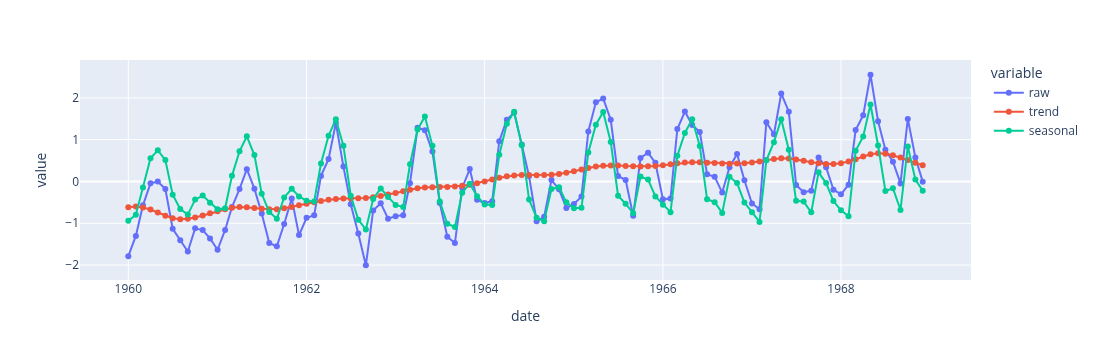

In [36]:
proc_data = {"date": df.date.values, "trend": ssa["Trend"].values, \
              "seasonal": ssa["Seasonal"], "raw":ssa["ssa_preprocessed"].values}
df_proc = pd.DataFrame.from_dict(proc_data, orient="columns")
# Create the line plot with markers
fig = px.line(df_proc, x="date", y=["raw","trend", "seasonal"], markers=True)

# Display the figure
fig.show()

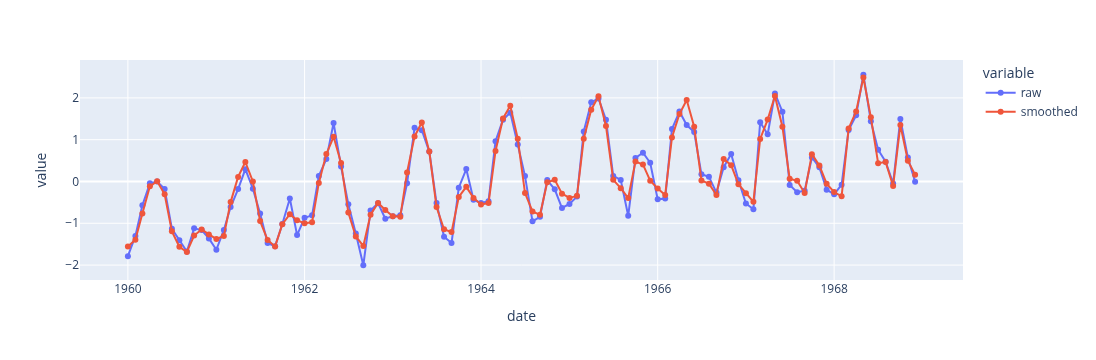

In [37]:
df_proc["smoothed"] = df_proc["trend"] + df_proc["seasonal"]
# Create the line plot with markers
fig = px.line(df_proc, x="date", y=["raw","smoothed"], markers=True)

# Display the figure
fig.show()

In [38]:
comments = "A gradual trend and two seasoalities, one occuring earlier in the year, the other occuring later."
comments += " The first seasonality appears to account for more variation. Trend accounts for about 25 percent and seasonality accounts for about 66 percent of the variation"
data = {"reconstruction_quality": "a very good",
        "notes_for_cycles_trends_seasonality": comments
}

j2_template = Template(ObservationTemplates.SMOOTHED_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SMOOTHED_PLOTS, rendered_output)
ts_obs.append(obs)

In [39]:
obs = (ObsCat.CHANGE_POINTS, ObservationTemplates.CHANGE_POINTS)
ts_obs.append(obs)


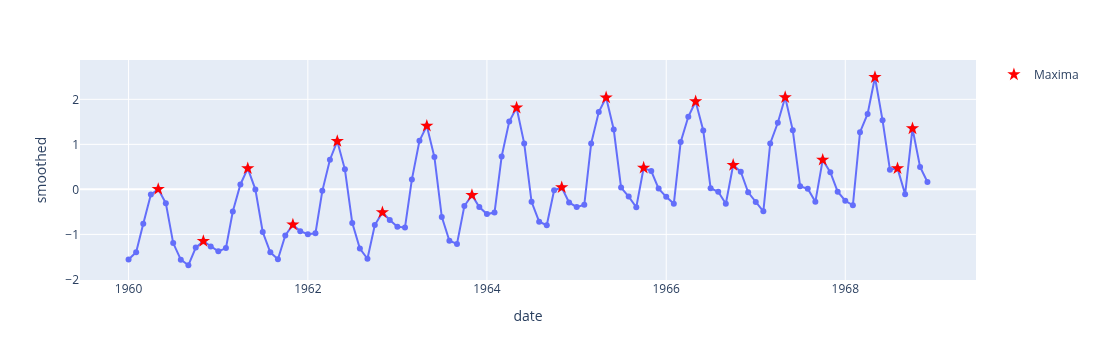

In [40]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
the_signal = df_proc.smoothed.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
fig = px.line(df_proc, x="date", y="smoothed", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Maxima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)


# Display the figure
fig.show()

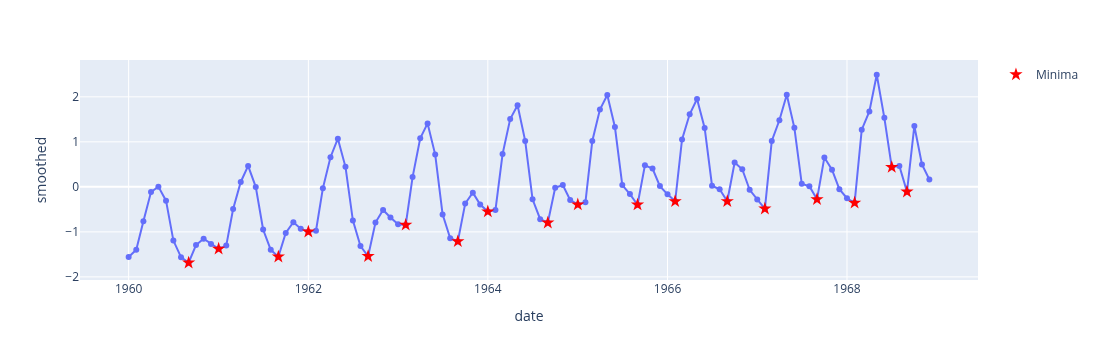

In [41]:

the_signal = -df_proc.smoothed.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
the_signal = df_proc.smoothed.values

# 3. Plot the results (optional, but helpful for visualization)
fig = px.line(df_proc, x="date", y="smoothed", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Minima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)



In [42]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Apply lowess
smoothed_05 = lowess(df_proc.raw, df_proc.date, frac=0.05) # frac is fraction of data used
smoothed_10 = lowess(df_proc.raw, df_proc.date, frac=0.1) # frac is fraction of data used
from scipy.signal import savgol_filter
# Apply filter: window size 51, polynomial order 3
smoothed_savgol_51 = savgol_filter(df_proc.raw, 51, 5)
smoothed_savgol_21 = savgol_filter(df_proc.raw, 21, 5)

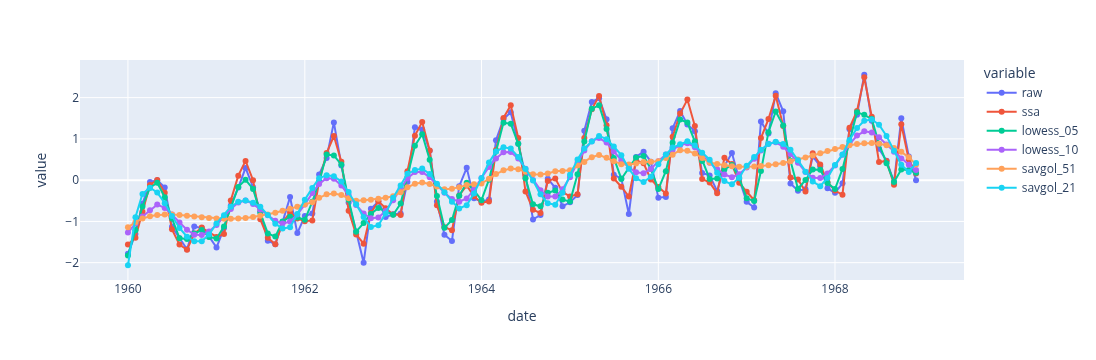

In [43]:
df_proc.rename(columns={"smoothed": "ssa"}, inplace=True)
df_proc["lowess_05"] = smoothed_05[:,1]
df_proc["lowess_10"] = smoothed_10[:,1]
df_proc["savgol_51"] = smoothed_savgol_51
df_proc["savgol_21"] = smoothed_savgol_21
fig = px.line(df_proc, x="date", y=["raw","ssa", "lowess_05", "lowess_10", "savgol_51", "savgol_21"], markers=True)

# Display the figure
fig.show()

In [44]:
df_cv.loc[7, "explained_variance"].item()

0.9422611931055342

In [45]:
data = {"noise_estimate": (1 - df_cv.loc[7, "explained_variance"].item())*100
}

j2_template = Template(ObservationTemplates.ESTIMATED_NOISE)
rendered_output = j2_template.render(data)
obs = (ObsCat.ESTIMATED_NOISE, rendered_output)
ts_obs.append(obs)

In [46]:
data = {"explained_variance": df_cv.loc[7, "explained_variance"].item()*100
}

j2_template = Template(ObservationTemplates.EXPLAINED_VARIANCE)
rendered_output = j2_template.render(data)
obs = (ObsCat.EXPLAINED_VARIANCE, rendered_output)
ts_obs.append(obs)

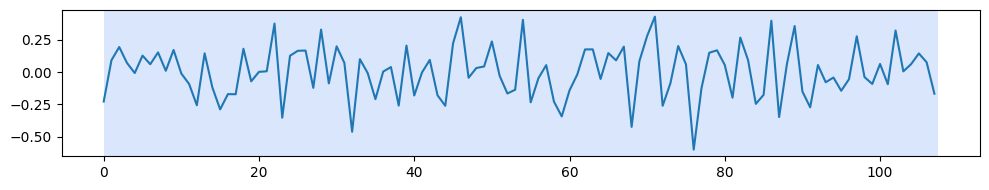

In [47]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=rec_pen)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

In [48]:
ac = "This dataset has trend and seasonal component"
ac += " The first component is the trend and explains about 25 percent of the variance, seasonality explains 66 percent of the variance"
ac += " Seasonality accounts for most of the variation as opposed to the other two datasets which are no seasonality, all trend or trend-cycles."
ac += " Since the Durbin-Watson statistic is in the 1.5 to 2.5 range (2.23), we can treat the noise as independent"
ac += " Further, PELT reported no change points in the noise, so we can treat the noise as Independent Identically Distributed"
ac += " If your downstream task, needs to approximate the data as the sum of a smooth signal with IID noise, with this data, it is a reasonable choice."
ac += " For this dataset, Monte-Carlo simulation may be a reasonable assumption. We can think of other realizations of this dataset to be."
ac += " similar to this dataset, for the entire period. The signal components lie within the confidence intervals obtained from the simulation."
data = {"correlated": "uncorrelated",
        "additional_comments": ac
       }

j2_template = Template(ObservationTemplates.SPECIFIC_COMMENTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SPECIFIC_COMMENTS, rendered_output)
ts_obs.append(obs)

In [49]:

file_path = "../data/car_sales_ts_observations.txt"
with open(file_path, 'w') as file:
    for cat, obs in ts_obs:
        # Convert the named tuple to a string and add a newline character
        file.write(f"Category: {cat.value}\n")
        file.write(f"Observation: {obs}\n")

## Knowledge Base Logging

In [50]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("coffee_prices_35_year_analysis", namespace=onto)

In [51]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [52]:
for cat, obs in ts_obs:
    observation_count += 1
    e = ExploratoryObservation(namespace=onto)
    e.finding = obs
    e.finding_sequence = observation_count
    e.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
    e.intent = IntentType.DATA_UNDERSTANDING.value
    exp_obs_list.append(e)

kaw.has_exploratory_observations = exp_obs_list 

In [53]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/car_sales_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")